In [1]:
import pandas as pd

df_modis = pd.read_csv(
    "../output/NDVI_modis.csv",
    parse_dates=["date"]
)

df_s2 = pd.read_csv(
    "../output/NDVI_S2.csv",
    parse_dates=["date"]
)

In [2]:
df_modis = df_modis.rename(
    columns={"mean_ndvi": "ndvi_modis"}
)

df_s2 = df_s2.rename(
    columns={"mean_ndvi_s2": "ndvi_s2"}
)

In [3]:
df_s2["date"] = pd.to_datetime(
    df_s2["date"]
).dt.normalize()

In [4]:
df_train = pd.merge(
    df_modis,
    df_s2,
    on="date",
    how="inner"
)

In [5]:
df_train

,date,ndvi_modis,ndvi_s2
0,2024-01-07,0.495,0.541
1,2024-01-22,0.538,0.540
2,2024-02-11,0.566,0.532
3,2024-03-12,0.589,0.498
4,2024-03-17,0.607,0.502
...,...,...,...
68,2026-04-08,0.616,0.565
69,2026-04-16,0.731,0.658
70,2026-04-18,0.715,0.625
71,2026-04-21,0.753,0.739


# LM with scikit

In [6]:
from sklearn.linear_model import LinearRegression

X = df_train[["ndvi_modis"]]
y = df_train["ndvi_s2"]

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


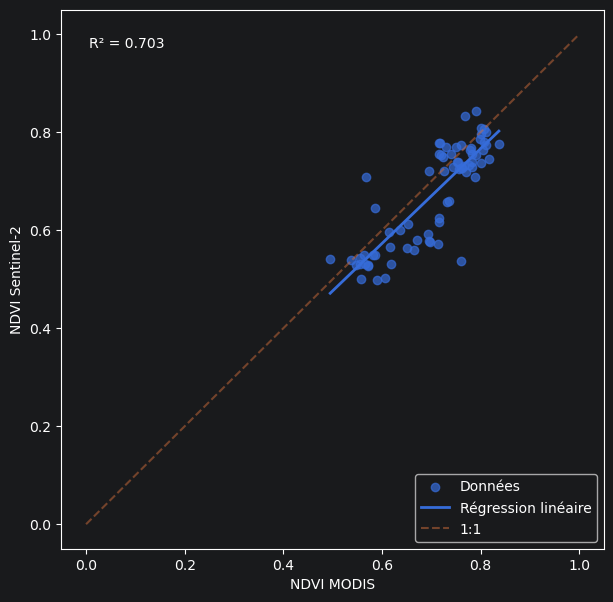

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# variables
X = df_train["ndvi_modis"]
y = df_train["ndvi_s2"]

# prédictions du modèle
y_pred = model.predict(df_train[["ndvi_modis"]])

# tri pour une ligne propre
order = np.argsort(X)

r2 = r2_score(y, y_pred)



# figure
fig, ax = plt.subplots(figsize=(7,7))

# points
ax.scatter(
    X,
    y,
    alpha=0.7,
    label="Données"
)

# droite de régression
ax.plot(
    X.iloc[order],
    y_pred[order],
    linewidth=2,
    label="Régression linéaire"
)

ax.text(
    0.05,
    0.95,
    f"R² = {r2:.3f}",
    transform=ax.transAxes,
    va="top"
)

ax.plot(
   [0,1],
   [0,1],
   linestyle="--",
   alpha=0.5,
   label="1:1"
)

ax.set_xlabel("NDVI MODIS")
ax.set_ylabel("NDVI Sentinel-2")

ax.legend()

plt.show()

In [9]:
df_modis["ndvi_s2_pred"] = model.predict(
    df_modis[["ndvi_modis"]]
)

In [10]:
dates_s2 = set(df_s2["date"])

In [11]:
df_modis["is_real_s2"] = df_modis["date"].isin(dates_s2)

df_inferred = df_modis[~df_modis["is_real_s2"]]

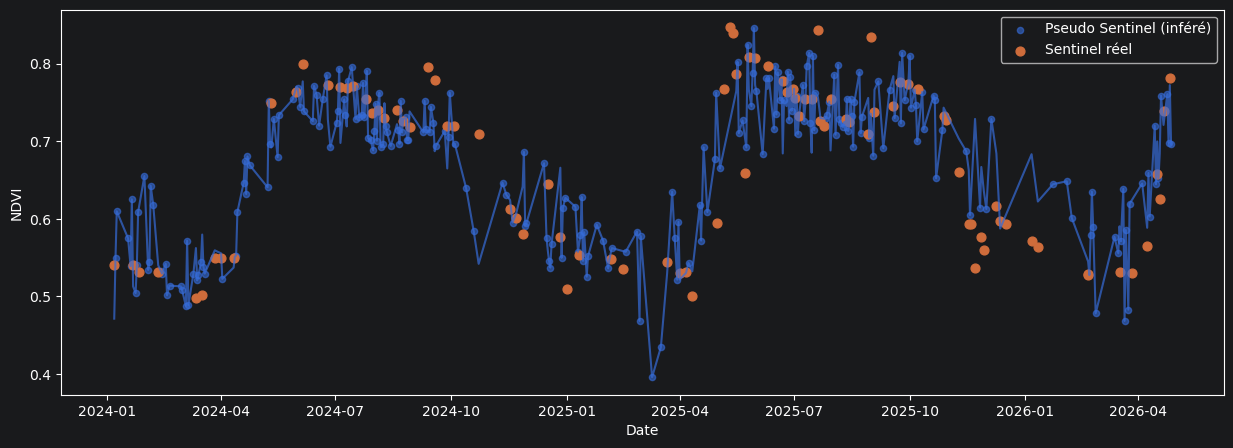

In [12]:
fig, ax = plt.subplots(figsize=(15,5))

# pseudo Sentinel inféré
ax.scatter(
    df_inferred["date"],
    df_inferred["ndvi_s2_pred"],
    s=20,
    alpha=0.6,
    label="Pseudo Sentinel (inféré)"
)

# vraies observations Sentinel
ax.scatter(
    df_s2["date"],
    df_s2["ndvi_s2"],
    s=40,
    label="Sentinel réel"
)

# ligne continue de phénologie
ax.plot(
    df_modis["date"],
    df_modis["ndvi_s2_pred"],
    alpha=0.7
)


ax.set_xlabel("Date")
ax.set_ylabel("NDVI")

ax.legend()

plt.show()

In [13]:
df_train["pred_train"] = model.predict(
    df_train[["ndvi_modis"]]
)

df_train["residual"] = (
    df_train["ndvi_s2"]
    - df_train["pred_train"]
)

In [14]:
sigma = df_train["residual"].std()

In [15]:
from scipy.signal import savgol_filter

In [16]:
df_modis = df_modis.sort_values("date")

In [17]:
df_modis["pred_smooth"] = savgol_filter(
    df_modis["ndvi_s2_pred"],
    window_length=21,
    polyorder=3
)

In [18]:
df_modis["lower"] = (
    df_modis["pred_smooth"] - sigma
)

df_modis["upper"] = (
    df_modis["pred_smooth"] + sigma
)

In [19]:
df_modis["lower_smooth"] = savgol_filter(
    df_modis["lower"],
    window_length=21,
    polyorder=3
)

df_modis["upper_smooth"] = savgol_filter(
    df_modis["upper"],
    window_length=21,
    polyorder=3
)

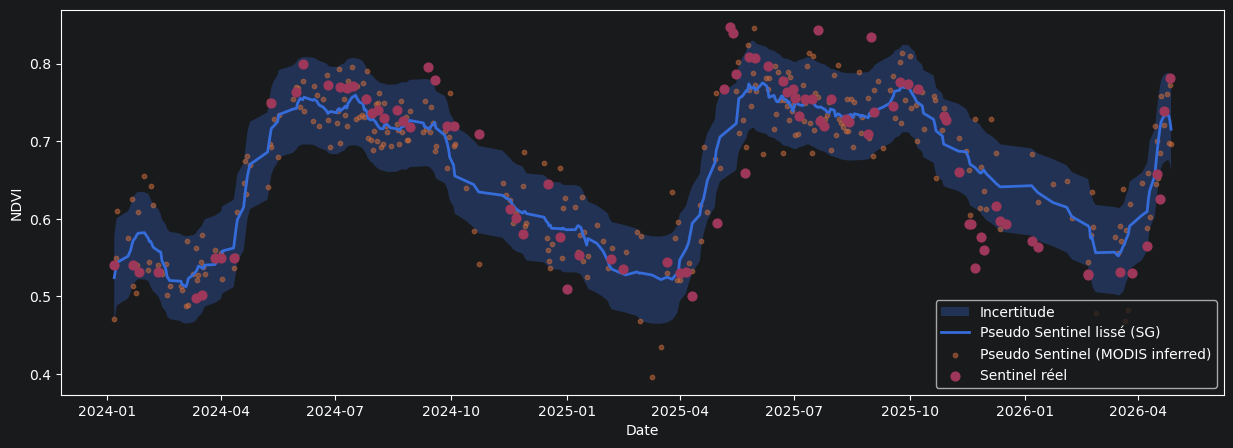

In [20]:
fig, ax = plt.subplots(figsize=(15,5))

# couloir lissé
ax.fill_between(
    df_modis["date"],
    df_modis["lower_smooth"],
    df_modis["upper_smooth"],
    alpha=0.3,
    label="Incertitude"
)

# courbe lissée
ax.plot(
    df_modis["date"],
    df_modis["pred_smooth"],
    linewidth=2,
    label="Pseudo Sentinel lissé (SG)"
)

# vrais points inférés non lissés
ax.scatter(
    df_modis["date"],
    df_modis["ndvi_s2_pred"],
    s=10,
    alpha=0.5,
    label="Pseudo Sentinel (MODIS inferred)"
)

# vraies observations Sentinel
ax.scatter(
    df_s2["date"],
    df_s2["ndvi_s2"],
    s=40,
    zorder=3,
    label="Sentinel réel"
)

ax.set_xlabel("Date")
ax.set_ylabel("NDVI")

ax.legend()

plt.show()